# AE for dimensionality reduction on Salinity, Temperature and Oxygen (STO) scaled data - GMM clustering

In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

2026-02-17 15:33:51.209079: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [4]:
# Standardize the features
scaler = StandardScaler()
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]','Depth_[m]']
df_ST_scaled = scaler.fit_transform(df_ST[features])

In [5]:
# set seed for reproducibility
tf.random.set_seed(seed)

# Autoencoder architecture
input_dim = df_ST_scaled.shape[1]
latent_dim = 2

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(8, activation='relu')(x)
latent = layers.Dense(latent_dim, name="latent")(x)

# Decoder
x = layers.Dense(8, activation='relu')(latent)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(input_dim)(x)

autoencoder = models.Model(inputs, outputs)
encoder = models.Model(inputs, latent)

In [6]:
early_stopping = EarlyStopping(
    monitor='val_loss',   # validation loss checked for early stopping
    patience=5,           # how many epochs to wait before stopping
    restore_best_weights=True
)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.fit(
    df_ST_scaled,
    df_ST_scaled,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 186s 1ms/step - loss: 0.0040 - val_loss: 0.0016
Epoch 2/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 186s 1ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 3/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 185s 1ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 4/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 191s 1ms/step - loss: 0.0018 - val_loss: 8.0046e-04
Epoch 5/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 182s 1ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 6/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 183s 1ms/step - loss: 0.0016 - val_loss: 8.5833e-04
Epoch 7/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 181s 1ms/step - loss: 0.0016 - val_loss: 8.1843e-04
Epoch 8/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 181s 1ms/step - loss: 0.0016 - val_loss: 9.0302e-04
Epoch 9/50
160354/160354 ━━━━━━━━━━━━━━━━━━━━ 181s 1ms/step - loss: 0.0018 - val_loss: 0.0011


356342/356342 ━━━━━━━━━━━━━━━━━━━━ 188s 528us/step


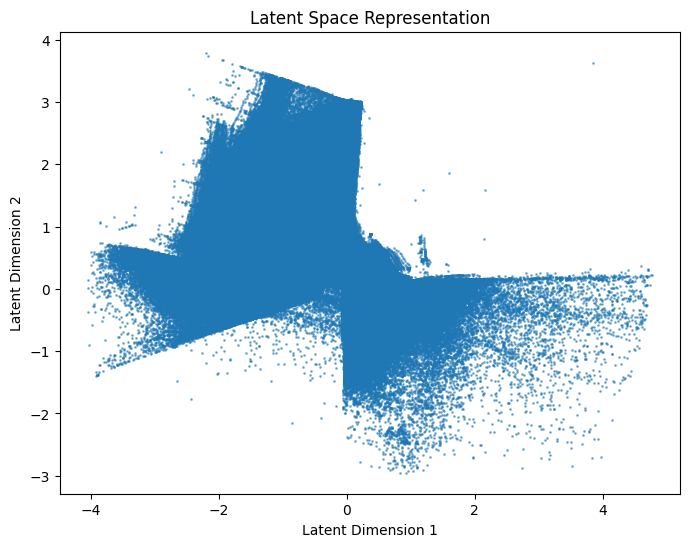

In [7]:
X_latent = encoder.predict(df_ST_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_latent[:,0], X_latent[:,1], s=1, alpha=0.5)
plt.title('Latent Space Representation')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()

In [8]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed)
    gmm.fit(X_latent)
    bic_scores.append(gmm.bic(X_latent))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

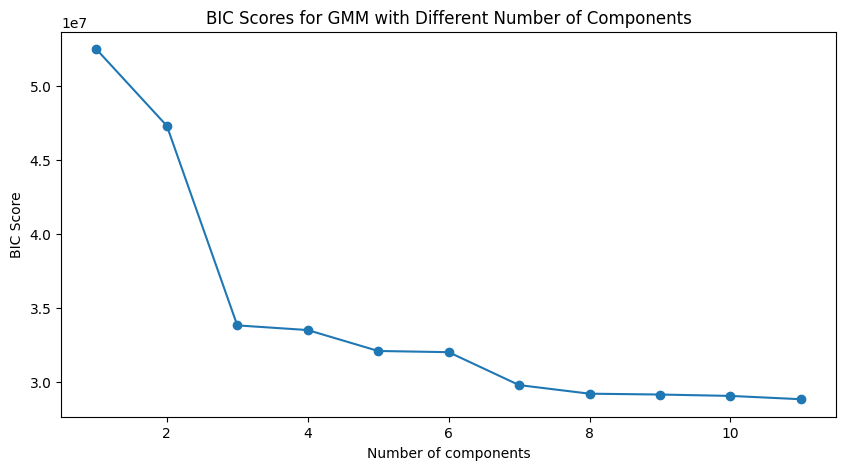

In [9]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [22]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 7

In [23]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_latent)

In [24]:
df_ST['gmm_label'] = labels

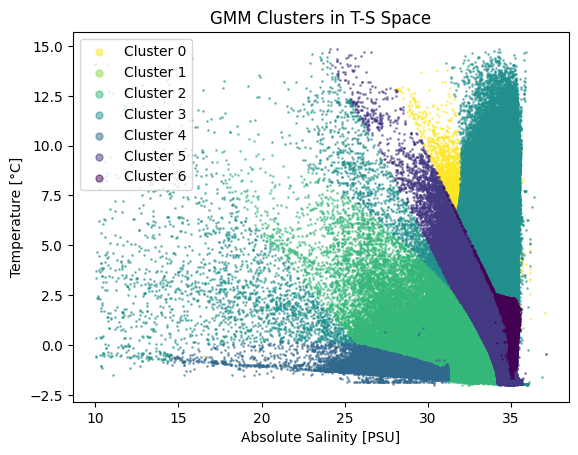

In [25]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_ST['gmm_label'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [26]:
# Sample geographically for better plotting
df_sampled = df_ST.sample(n=100000, random_state=seed)

In [27]:
# Compute data centroid (mean location)
center_lat = df_ST['Latitude_[deg_N]'].mean()
center_lon = df_ST['Longitude_[deg_E]'].mean()

colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma, # Colour scale same as continuous colour bar version but sampled to be discrete
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig = px.scatter_geo(
    df_sampled,
    lat='Latitude_[deg_N]',
    lon='Longitude_[deg_E]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="GMM clusters using TSO on geographic map"
)

fig.update_traces(
    marker=dict(size=5, opacity=0.9)
)

fig.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig.add_trace(
        go.Scattergeo(
            lat=[None], lon=[None],   # invisible
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=center_lat, lon=center_lon),
    showcoastlines=True,
    showcountries=True
)

fig.update_layout(
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig.show()

In [16]:
# Plot in 3D
colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma,
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig_3d = px.scatter_3d(
    df_sampled,
    x='Latitude_[deg_N]',
    y='Longitude_[deg_E]',
    z='Depth_[m]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="3D Scatter Lat-Lon-Depth plot of GMM clusters"
)

fig_3d.update_traces(
    marker=dict(
        size=5
    )
)

fig_3d.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig_3d.add_trace(
        go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig_3d.update_layout(
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')
    ),
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig_3d.show()

In [17]:
def cross_sec_lon(lat_value, tol=0.5):
    df_lon_slice = df_ST[
        (df_ST['Longitude_[deg_E]'] >= lat_value - tol) &
        (df_ST['Longitude_[deg_E]'] <= lat_value + tol)
    ]

    n = optimal_n_components

    # Sample full sequential colormap discretely
    base_cmap = plt.cm.viridis
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)

    # Discrete normalization
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    plt.figure(figsize=(10, 6))

    sc = plt.scatter(
        df_lon_slice['Latitude_[deg_N]'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label'],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.6
    )

    plt.gca().invert_yaxis()
    plt.xlabel('Longitude [deg E]')
    plt.ylabel('Depth [m]')
    plt.title(f'GMM Clusters in Longitude-Depth Cross Section at Latitude ~ {lat_value}°N')

    # ---- Discrete legend (dummy handles) ----
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=6,
            markerfacecolor=colors[i],
            markeredgecolor='none',
            label=f'Cluster {i}'
        )
        for i in range(n)
    ]

    plt.legend(
        handles=handles,
        title='GMM Cluster',
        loc='lower left',
    )

    plt.tight_layout()
    plt.show()

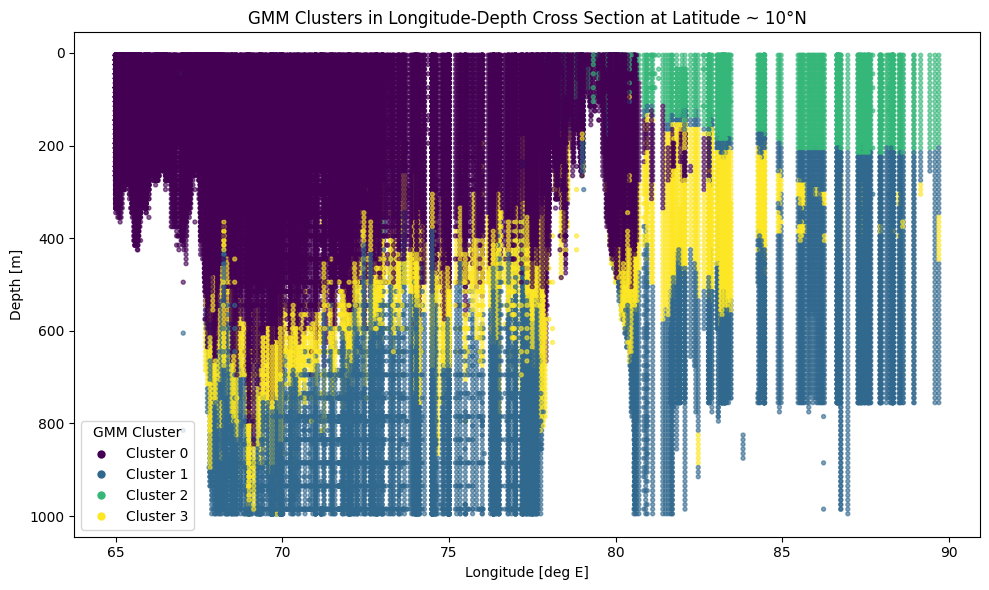

In [18]:
# Plot cross section for specific longitude slice
lat_val= 10
cross_sec_lon(lat_val, tol=0.5)

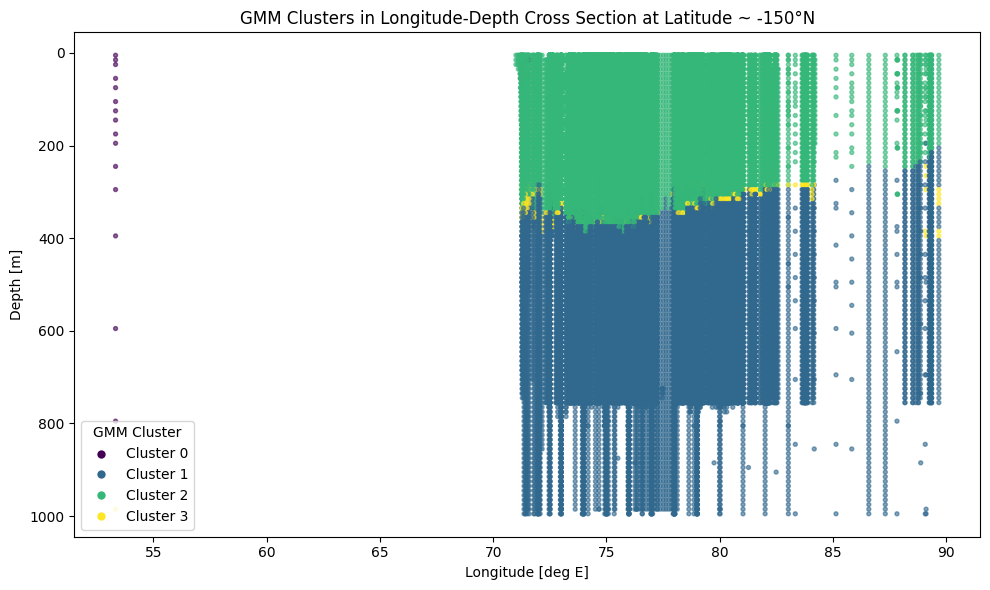

In [19]:
lat_val= -150
cross_sec_lon(lat_val, tol=0.5)

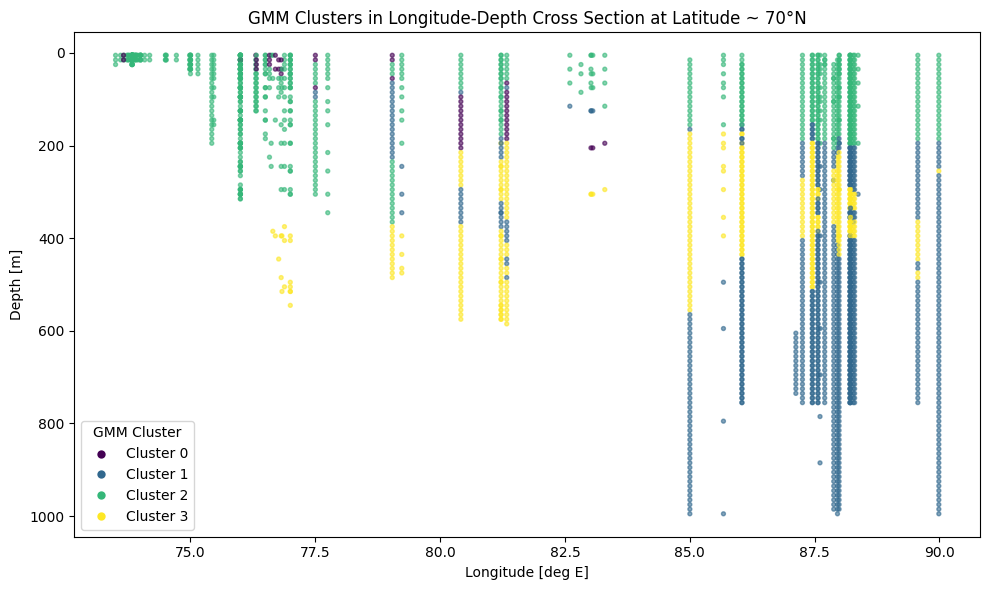

In [20]:
lat = 70
cross_sec_lon(lat, tol=0.5)

In [21]:
# Loss of information
X_recon_ae = autoencoder.predict(df_ST_scaled)
mse = np.mean((df_ST_scaled - X_recon_ae) ** 2)
print(f'Mean Squared Error of AE reconstruction: {mse}')

356342/356342 ━━━━━━━━━━━━━━━━━━━━ 200s 562us/step
Mean Squared Error of AE reconstruction: 0.0016055105801739173


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

def cross_sec_lon(lon_value, tol=0.5):

    # ---------------------------------------------------------
    # Slice data at fixed longitude
    # ---------------------------------------------------------
    df_slice = df_ST[
        (df_ST['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_ST['Longitude_[deg_E]'] <= lon_value + tol)
    ]

    n = optimal_n_components

    # ---------------------------------------------------------
    # Colormap
    # ---------------------------------------------------------
    base_cmap = plt.cm.viridis
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    fig, ax = plt.subplots(figsize=(12, 6))

    # ---------------------------------------------------------
    # Scatter plot (Latitude vs Depth)
    # ---------------------------------------------------------
    ax.scatter(
        df_slice['Latitude_[deg_N]'],   # X-axis = latitude
        df_slice['Depth_[m]'],          # Y-axis = depth
        c=df_slice['gmm_label'],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.6
    )

    # =========================================================
    #  TOPOGRAPHY / BATHYMETRY
    # =========================================================
    # df_topo must contain:
    # 'Latitude', 'Longitude', 'Elevation_m'
    # Elevation_m > 0 = land, < 0 = ocean

    df_topo_slice = df_topo[
        (df_topo['Longitude'] >= lon_value - tol) &
        (df_topo['Longitude'] <= lon_value + tol)
    ].sort_values('Latitude')

    # Plot seafloor profile
    ax.plot(
        df_topo_slice['Latitude'],
        -df_topo_slice['Elevation_m'],   # flip sign for depth axis
        color='black',
        linewidth=1.5,
        zorder=3
    )

    # Shade land
    ax.fill_between(
        df_topo_slice['Latitude'],
        -df_topo_slice['Elevation_m'],
        0,
        where=df_topo_slice['Elevation_m'] > 0,
        color='lightgray',
        alpha=0.8,
        zorder=4
    )

    # =========================================================
    #  GEOGRAPHIC LABELS
    # =========================================================
    # Since x-axis is LATITUDE, labels must use latitude position

    # Bering Strait latitude ≈ 65.8°N
    if abs(lon_value + 168) < 5:  # only label if section is near Bering Strait longitude
        ax.text(
            65.8,
            150,
            "Bering Strait",
            fontsize=10,
            rotation=90,
            verticalalignment='bottom'
        )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------
    ax.invert_yaxis()
    ax.set_xlabel('Latitude [°N]')
    ax.set_ylabel('Depth [m]')
    ax.set_title(f'GMM Clusters in Latitude–Depth Section at Longitude ≈ {lon_value}°E')

    # ---------------------------------------------------------
    # Discrete legend
    # ---------------------------------------------------------
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=6,
            markerfacecolor=colors[i],
            markeredgecolor='none',
            label=f'Cluster {i}'
        )
        for i in range(n)
    ]

    ax.legend(handles=handles, title='GMM Cluster', loc='lower left')

    plt.tight_layout()
    plt.show()


NameError: name 'df_topo' is not defined

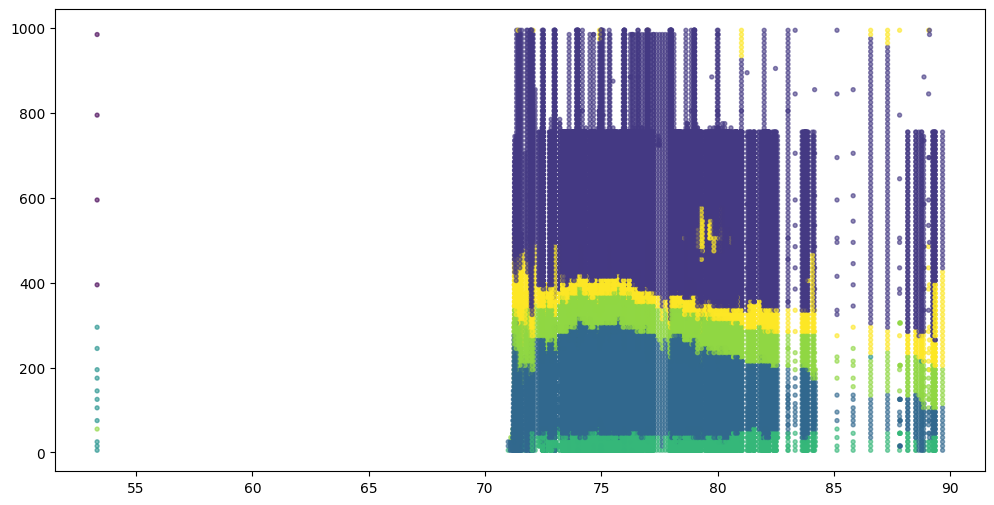

In [29]:
cross_sec_lon(lon_value=-150, tol=0.5)